In [1]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3"
)

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 42197.74it/s]


In [2]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str
    rewrite_count: int

In [3]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [4]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [5]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {"context": docs}

In [6]:
from langsmith import Client
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError
from google.genai.errors import ServerError

client = Client()
generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
)

# SDK 기본 재시도는 비활성화하고, LangChain with_retry로 지수 백오프 적용
# 429(ClientError)는 ChatGoogleGenerativeAIError로, 503(ServerError)은 그대로 전파됨
RETRY_KWARGS = {
    "retry_if_exception_type": (ChatGoogleGenerativeAIError, ServerError),
    "wait_exponential_jitter": True,
    "stop_after_attempt": 5,
    "exponential_jitter_params": {"initial": 3, "max": 90},
}

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", max_retries=1)

In [7]:
def generate(state: AgentState):
    context = state["context"]
    question = state["query"]
    # structured prompt는 LLM에 직접 pipe 후, 체인 전체에 retry 적용
    rag_chain = (generate_prompt | llm).with_retry(**RETRY_KWARGS)
    response = rag_chain.invoke({"question": question, "context": context})
    return {"answer": response}

In [8]:
relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
)

In [9]:
from typing import Literal

MAX_REWRITE_COUNT = 3

def check_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    if state.get('rewrite_count', 0) >= MAX_REWRITE_COUNT:
        return 'generate'

    context = state["context"]
    print(f'context == {context}')

    if not context:
        print('context가 비어 있어 relevance LLM 호출을 건너뜁니다.')
        return 'rewrite'

    question = state["query"]
    relevance_chain = (relevance_prompt | llm).with_retry(**RETRY_KWARGS)
    response = relevance_chain.invoke({"question": question, "documents": context})
    print(f'doc relevanceresponse == {response}')
    if response['Score'] == 1:
        return 'generate'
    return 'rewrite'

In [10]:
query = "연봉 5천만원 직장인의 소득세는?"

In [11]:
from langchain_core.prompts import PromptTemplate

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(
    f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    만약 변경할 필요가 없다고 판단된다면, 사용자의 질문을 변경하지 않아도 됩니다.
    사전: {dictionary}
    질문: {{query}}
    """
)

In [12]:
from langchain_core.output_parsers import StrOutputParser

def rewrite(state: AgentState):
    question = state["query"]
    rewrite_chain = (rewrite_prompt | llm | StrOutputParser()).with_retry(**RETRY_KWARGS)
    response = rewrite_chain.invoke({"query": question})
    return {
        "query": response,
        "rewrite_count": state.get("rewrite_count", 0) + 1,
    }


In [13]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [14]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)


In [15]:
graph = graph_builder.compile()

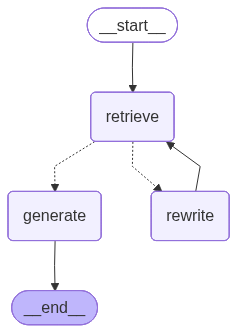

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
initial_state = {'query': '연봉 5천만원 세금', 'rewrite_count': 0}
graph.invoke(initial_state)

context == [Document(id='278f836e-41ee-46e3-9e3f-ed7936dc465a', metadata={'source': './documents/income_tax.txt'}, page_content='⑥ 제5항 단서에도 불구하고 장기주택저당차입금이 다음 각 호의 어느 하나에 해당하는 경우에는 연 800만원 대신 그 해당 각 호의 액면을 공개한도로 하여 제8항 본문을 적용한다.<신설 2014. 12. 23, 2013. 12. 31.>\n  1. 차입금의 상환기간이 15년 이상 장기주택저당차입금의 이자를 대봉정림으로 정하고 교정림(이하 이 항에서 “고정금리라 한다”)이라고 하며 차입금을 대봉정림으로 정한 경우에 비거주자 분당상환 방식으로 상환하는 경우: 2천만원\n  2. 차입금의 상환기간이 15년 이상 장기주택저당차입금의 이자를 고정금리로 지급하거나 그 차입금을 비거주자 분당상환으로 상환하는 경우: 1천800만원\n  3. 차입금의 상환기간이 10년 이상 장기주택저당차입금의 이자를 고정금리로 지급하거나 그 차입금을 비거주자 분당상환으로 상환하는 경우: 600만원\n  <삭제 2014. 1. 1.>\n제1항 및 제5항에 따른 공지는 해당 거주자가 대봉정림으로 정한 바에 따라 신청한 경우에 적용하며, 공개액이 거주자의 해당 각 기간의 합산소득금액을 초과하는 경우 그 초과하는 금액은 없는 것으로 한다.<개정 2014. 1. 1., 2014. 1.>\n<삭제 2014. 1. 1.>\n<삭제 2014. 1. 1.>\n제1항 및 제5항에 따른 공지는 “특별소득공제”란 한다.<개정 2014. 1. 1.>\n특별소득공제에 관해서는 그 밖에 필요한 사항을 대봉정림으로 정한다.<개정 2014. 1. 1.>\n제53조(생재를 같이 하는 부양가족의 범위와 판단기준) 제50조에 규정된 생계를 같이 하는 부양가족의 주민등록표 상의 동거가족으로서 해당 거주자의 주소 또는 거소에 실질적으로 생계를 같이 하는 사람으로 판단한다. 단, 자치법령에 의한 경우는 그러

{'query': '연봉 5천만원 세금',
 'context': [Document(id='278f836e-41ee-46e3-9e3f-ed7936dc465a', metadata={'source': './documents/income_tax.txt'}, page_content='⑥ 제5항 단서에도 불구하고 장기주택저당차입금이 다음 각 호의 어느 하나에 해당하는 경우에는 연 800만원 대신 그 해당 각 호의 액면을 공개한도로 하여 제8항 본문을 적용한다.<신설 2014. 12. 23, 2013. 12. 31.>\n  1. 차입금의 상환기간이 15년 이상 장기주택저당차입금의 이자를 대봉정림으로 정하고 교정림(이하 이 항에서 “고정금리라 한다”)이라고 하며 차입금을 대봉정림으로 정한 경우에 비거주자 분당상환 방식으로 상환하는 경우: 2천만원\n  2. 차입금의 상환기간이 15년 이상 장기주택저당차입금의 이자를 고정금리로 지급하거나 그 차입금을 비거주자 분당상환으로 상환하는 경우: 1천800만원\n  3. 차입금의 상환기간이 10년 이상 장기주택저당차입금의 이자를 고정금리로 지급하거나 그 차입금을 비거주자 분당상환으로 상환하는 경우: 600만원\n  <삭제 2014. 1. 1.>\n제1항 및 제5항에 따른 공지는 해당 거주자가 대봉정림으로 정한 바에 따라 신청한 경우에 적용하며, 공개액이 거주자의 해당 각 기간의 합산소득금액을 초과하는 경우 그 초과하는 금액은 없는 것으로 한다.<개정 2014. 1. 1., 2014. 1.>\n<삭제 2014. 1. 1.>\n<삭제 2014. 1. 1.>\n제1항 및 제5항에 따른 공지는 “특별소득공제”란 한다.<개정 2014. 1. 1.>\n특별소득공제에 관해서는 그 밖에 필요한 사항을 대봉정림으로 정한다.<개정 2014. 1. 1.>\n제53조(생재를 같이 하는 부양가족의 범위와 판단기준) 제50조에 규정된 생계를 같이 하는 부양가족의 주민등록표 상의 동거가족으로서 해당 거주자의 주소 또는 거소에 실질적으로 생계를 같이 하는 사람으로